# Vitamin C: Supplier Quality Inference & External Data Strategy

Can we infer quality differences between Vitamin C suppliers from the database alone? What external data would we need to make real sourcing decisions?

**Spoiler:** The database reveals *what* each company buys and *which chemical form* they use — but has zero quality/price/compliance fields. The real value comes from combining internal structure with external enrichment.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (14, 7)
matplotlib.rcParams['font.size'] = 11
sns.set_style("whitegrid")

DB_PATH = "../data/db.sqlite"
conn = sqlite3.connect(DB_PATH)

product = pd.read_sql("SELECT * FROM Product", conn)
company = pd.read_sql("SELECT * FROM Company", conn)
bom = pd.read_sql("SELECT * FROM BOM", conn)
bom_component = pd.read_sql("SELECT * FROM BOM_Component", conn)
supplier = pd.read_sql("SELECT * FROM Supplier", conn)
supplier_product = pd.read_sql("SELECT * FROM Supplier_Product", conn)

# All vitamin-C-related raw materials
vc_mask = product.SKU.str.contains("vitamin-c|ascorb", case=False, na=False)
vc_products = product[vc_mask & (product.Type == "raw-material")].copy()
print(f"Vitamin C raw material products: {len(vc_products)}")

Vitamin C raw material products: 31


## 1. Chemical Forms of Vitamin C in the Data

The SKU names encode the **chemical form** — this is the single most important quality signal available internally. Different forms have fundamentally different properties, bioavailability, stability, and target applications.

Vitamin C forms in the database:

  Vitamin C (unspecified form)          13 products
  Ascorbic Acid                         10 products
  Ascorbyl Palmitate                     4 products
  Calcium Ascorbate                      2 products
  Sodium Ascorbate                       1 products
  L-Ascorbic Acid (explicit)             1 products


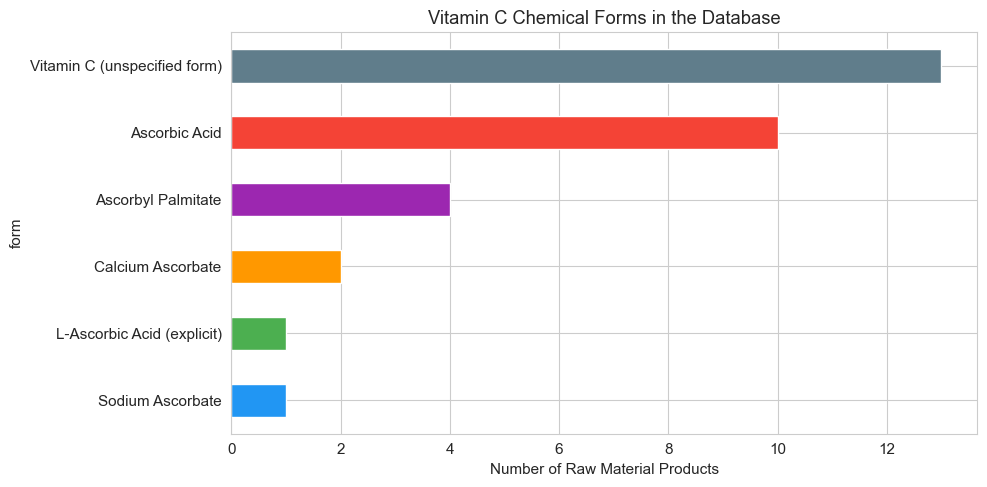

In [2]:
# Parse the chemical form from each SKU
def extract_vc_form(sku):
    parts = sku.split("-")
    if len(parts) >= 4 and parts[0] == "RM":
        raw = "-".join(parts[2:-1])
    else:
        raw = sku
    return raw

vc_products["form_raw"] = vc_products["SKU"].apply(extract_vc_form)

# Normalize to canonical chemical forms
def classify_form(form):
    form_l = form.lower()
    if "ascorbyl-palmitate" in form_l:
        return "Ascorbyl Palmitate"
    elif "calcium-ascorbate" in form_l:
        return "Calcium Ascorbate"
    elif "sodium-ascorbate" in form_l:
        return "Sodium Ascorbate"
    elif "l-ascorbic-acid" in form_l:
        return "L-Ascorbic Acid (explicit)"
    elif "ascorbic-acid" in form_l:
        return "Ascorbic Acid"
    else:
        return "Vitamin C (unspecified form)"

vc_products["form"] = vc_products["form_raw"].apply(classify_form)
vc_products = vc_products.merge(company, left_on="CompanyId", right_on="Id", suffixes=("", "_co"))

form_counts = vc_products["form"].value_counts()
print("Vitamin C forms in the database:\n")
for form, count in form_counts.items():
    print(f"  {form:35s}  {count:>3} products")

fig, ax = plt.subplots(figsize=(10, 5))
form_counts.sort_values().plot.barh(ax=ax, color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#607D8B"])
ax.set_xlabel("Number of Raw Material Products")
ax.set_title("Vitamin C Chemical Forms in the Database")
plt.tight_layout()
plt.show()

In [3]:
# Which companies use which form?
form_company = vc_products[["form", "Name"]].drop_duplicates().sort_values(["form", "Name"])

print("Companies by Vitamin C form:\n")
for form in form_company["form"].unique():
    cos = form_company[form_company.form == form]["Name"].tolist()
    print(f"  {form}")
    print(f"    {', '.join(cos)}\n")

Companies by Vitamin C form:

  Ascorbic Acid
    ALL ONE, Body Fortress, Equate, Kirkland Signature, Liquid I.V., Nature's Nutrition, One A Day, PRIME HYDRATION+, Walgreens, up&up

  Ascorbyl Palmitate
    Equate, NOW Foods, Nature's Bounty, Walgreens

  Calcium Ascorbate
    TREVI, Ultima Replenisher

  L-Ascorbic Acid (explicit)
    NutriBiotic

  Sodium Ascorbate
    Equate

  Vitamin C (unspecified form)
    BBEEAAUU, Body Fortress, BodyTech, Centrum, Equate, Nature Made, New Chapter, One A Day, PowderVitamin, The Vitamin Shoppe, Vitacost, Wellmade, up&up



### Chemical Form Reference

| Form | Solubility | Key Properties | Typical Use |
|---|---|---|---|
| **Ascorbic Acid** | Water-soluble | Cheapest, most common; acidic (pH ~2.5); degrades with heat/light/oxygen | Tablets, powders, capsules, beverages |
| **Ascorbyl Palmitate** | Fat-soluble | Ester of ascorbic acid + palmitic acid; antioxidant preservative; lower bioavailability as vitamin C | Softgels, oil-based formulas, as preservative |
| **Calcium Ascorbate** | Water-soluble | Buffered (pH ~7); gentler on stomach; provides ~10% calcium | Sensitive-stomach formulas, electrolyte drinks |
| **Sodium Ascorbate** | Water-soluble | Buffered (pH ~7); gentler on stomach; adds sodium | IV formulations, buffered supplements |
| **L-Ascorbic Acid** | Water-soluble | Same as ascorbic acid but explicitly specifying the bioactive L-enantiomer | Premium / pharma-grade positioning |

**Key insight:** The form choice is *not* interchangeable. Substituting calcium ascorbate for ascorbyl palmitate would change the product's solubility profile, bioavailability, and potentially its compliance status. Form-level matching is the minimum requirement for any sourcing consolidation.

## 2. Supplier Landscape: What the Database Tells Us

In [4]:
# Which suppliers provide vitamin C products?
vc_supplier = (
    supplier_product
    .merge(vc_products[["Id", "SKU", "form", "Name"]], left_on="ProductId", right_on="Id")
    .merge(supplier, left_on="SupplierId", right_on="Id", suffixes=("_company", "_supplier"))
)

supplier_summary = (
    vc_supplier.groupby("Name_supplier")
    .agg(
        n_products=("ProductId", "nunique"),
        n_companies=("Name_company", "nunique"),
        forms=("form", lambda x: sorted(x.unique())),
        companies=("Name_company", lambda x: sorted(x.unique())),
    )
    .reset_index()
    .rename(columns={"Name_supplier": "Supplier"})
)

print("=== SUPPLIERS FOR VITAMIN C ===\n")
for _, row in supplier_summary.iterrows():
    print(f"Supplier: {row['Supplier']}")
    print(f"  Products:  {row['n_products']}")
    print(f"  Companies: {row['n_companies']}")
    print(f"  Forms:     {', '.join(row['forms'])}")
    print()

# Check: do both suppliers serve exactly the same products?
supplier_products_sets = (
    vc_supplier.groupby("Name_supplier")["ProductId"]
    .apply(set)
    .to_dict()
)
suppliers = list(supplier_products_sets.keys())
if len(suppliers) == 2:
    s1, s2 = suppliers
    overlap = supplier_products_sets[s1] & supplier_products_sets[s2]
    only_s1 = supplier_products_sets[s1] - supplier_products_sets[s2]
    only_s2 = supplier_products_sets[s2] - supplier_products_sets[s1]
    print(f"Product overlap between {s1} and {s2}:")
    print(f"  Both supply:    {len(overlap)} products")
    print(f"  Only {s1}: {len(only_s1)} products")
    print(f"  Only {s2}: {len(only_s2)} products")

=== SUPPLIERS FOR VITAMIN C ===

Supplier: Prinova USA
  Products:  31
  Companies: 24
  Forms:     Ascorbic Acid, Ascorbyl Palmitate, Calcium Ascorbate, L-Ascorbic Acid (explicit), Sodium Ascorbate, Vitamin C (unspecified form)

Supplier: PureBulk
  Products:  31
  Companies: 24
  Forms:     Ascorbic Acid, Ascorbyl Palmitate, Calcium Ascorbate, L-Ascorbic Acid (explicit), Sodium Ascorbate, Vitamin C (unspecified form)

Product overlap between Prinova USA and PureBulk:
  Both supply:    31 products
  Only Prinova USA: 0 products
  Only PureBulk: 0 products


### Finding: The database has NO quality differentiation between suppliers

Both **Prinova USA** and **PureBulk** supply the exact same 31 Vitamin C products. The `Supplier_Product` table is purely a binary mapping (supplier can supply product — yes/no). There are **no columns** for:
- Price / unit cost
- Lead time
- Minimum order quantity (MOQ)
- Country of origin
- Purity / grade
- Certifications

**This means quality inference must come from indirect signals and external enrichment.**

## 3. Indirect Quality Signals We CAN Infer

Even without explicit quality fields, the database structure lets us infer several things.

### 3a. Product Context Inference — What the BOM co-ingredients reveal

The other ingredients in a BOM tell us what *type* of product the Vitamin C goes into. This constrains quality requirements: a pharma-grade multivitamin tablet has different needs than an electrolyte drink powder.

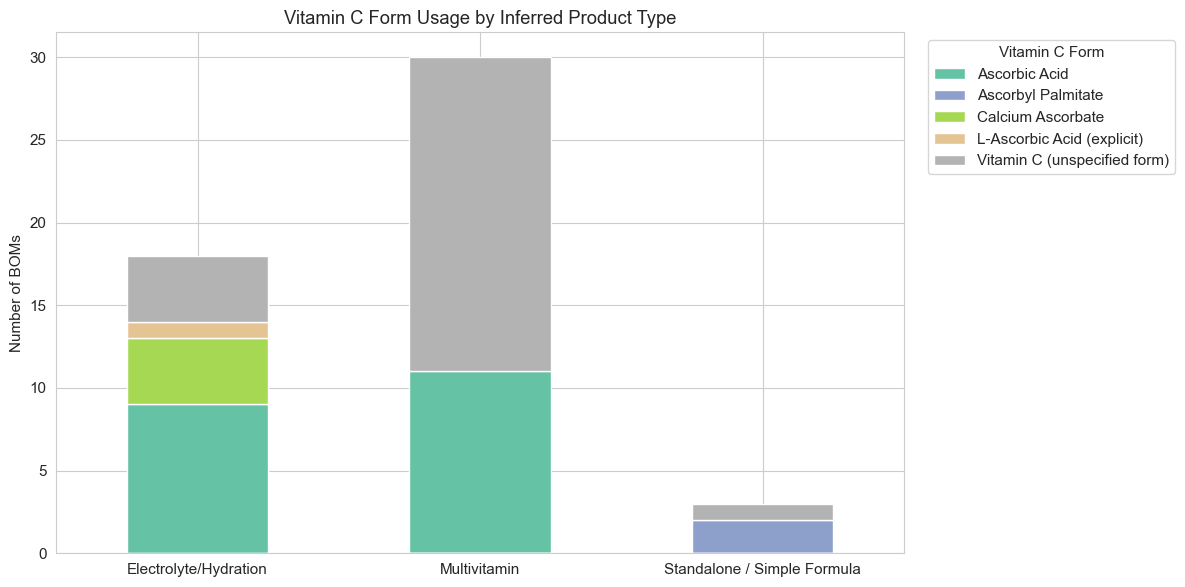

,Inferred Product Type,Vitamin C Form,BOMs
0,Electrolyte/Hydration,Ascorbic Acid,9
1,Electrolyte/Hydration,Calcium Ascorbate,4
3,Electrolyte/Hydration,Vitamin C (unspecified form),4
2,Electrolyte/Hydration,L-Ascorbic Acid (explicit),1
5,Multivitamin,Vitamin C (unspecified form),19
4,Multivitamin,Ascorbic Acid,11
6,Standalone / Simple Formula,Ascorbyl Palmitate,2
7,Standalone / Simple Formula,Vitamin C (unspecified form),1


In [5]:
# For each BOM that uses vitamin C, get all co-ingredients
vc_bom_ids = (
    bom_component.merge(vc_products[["Id"]], left_on="ConsumedProductId", right_on="Id")
    ["BOMId"].unique()
)

all_bom_data = (
    bom_component[bom_component.BOMId.isin(vc_bom_ids)]
    .merge(bom, left_on="BOMId", right_on="Id")
    .merge(product.rename(columns={"Id": "FGId", "SKU": "FG_SKU", "CompanyId": "FG_CoId"}),
           left_on="ProducedProductId", right_on="FGId")
    .merge(product.rename(columns={"Id": "RMId", "SKU": "RM_SKU"}),
           left_on="ConsumedProductId", right_on="RMId")
    .merge(company, left_on="FG_CoId", right_on="Id")
)

def extract_ingredient(sku):
    parts = sku.split("-")
    if len(parts) >= 4 and parts[0] == "RM":
        return "-".join(parts[2:-1])
    return sku

all_bom_data["ingredient"] = all_bom_data["RM_SKU"].apply(extract_ingredient)

# Classify product type from co-ingredients
PRODUCT_TYPE_SIGNALS = {
    "Multivitamin": ["vitamin-a", "vitamin-d", "vitamin-e", "vitamin-k", "biotin", "folate",
                     "thiamin", "riboflavin", "niacin", "b-vitamin", "pantothenic"],
    "Electrolyte/Hydration": ["electrolyte", "sodium", "potassium", "dextrose", "salt",
                              "citric-acid", "rebaudioside"],
    "Protein Supplement": ["whey", "protein", "bcaa", "leucine", "creatine", "amino"],
    "Standalone Vitamin C": [],  # fallback: few co-ingredients
}

def infer_product_type(bom_ingredients):
    scores = {}
    for ptype, keywords in PRODUCT_TYPE_SIGNALS.items():
        if ptype == "Standalone Vitamin C":
            continue
        scores[ptype] = sum(1 for kw in keywords if any(kw in ing for ing in bom_ingredients))
    best = max(scores, key=scores.get)
    if scores[best] == 0 or len(bom_ingredients) <= 5:
        return "Standalone / Simple Formula"
    return best

bom_types = []
for bom_id in vc_bom_ids:
    bom_data = all_bom_data[all_bom_data.BOMId == bom_id]
    ingredients = bom_data["ingredient"].tolist()
    fg_sku = bom_data.iloc[0]["FG_SKU"]
    co_name = bom_data.iloc[0]["Name"]

    # Find which VC form this BOM uses
    vc_ingredients = [i for i in ingredients if any(k in i for k in ["vitamin-c", "ascorb"])]
    vc_form = classify_form(vc_ingredients[0]) if vc_ingredients else "Unknown"

    ptype = infer_product_type(ingredients)
    bom_types.append({
        "BOMId": bom_id,
        "Company": co_name,
        "FG_SKU": fg_sku,
        "Vitamin C Form": vc_form,
        "Inferred Product Type": ptype,
        "Total Ingredients": len(ingredients),
    })

bom_types_df = pd.DataFrame(bom_types)

# Visualize: form usage by product type
ct = pd.crosstab(bom_types_df["Inferred Product Type"], bom_types_df["Vitamin C Form"])
fig, ax = plt.subplots(figsize=(12, 6))
ct.plot.bar(ax=ax, stacked=True, colormap="Set2", edgecolor="white")
ax.set_ylabel("Number of BOMs")
ax.set_title("Vitamin C Form Usage by Inferred Product Type")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Vitamin C Form", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(bom_types_df.groupby(["Inferred Product Type", "Vitamin C Form"]).size()
        .reset_index(name="BOMs").sort_values(["Inferred Product Type", "BOMs"], ascending=[True, False]))

### 3b. Supplier Breadth as a Quality Proxy

Even though both suppliers cover the same Vitamin C products, their **overall portfolio breadth** across all ingredients differs. A supplier that covers more ingredient categories may be a distributor/broker (broad but shallow), while a specialist may signal deeper quality control for specific ingredients.

In [6]:
# Full portfolio analysis for Prinova USA and PureBulk
vc_suppliers = ["Prinova USA", "PureBulk"]
all_sp = (
    supplier_product
    .merge(supplier, left_on="SupplierId", right_on="Id")
    .merge(product, left_on="ProductId", right_on="Id", suffixes=("_sup", "_prod"))
)
all_sp["ingredient"] = all_sp["SKU"].apply(extract_ingredient)

CATEGORIES = {
    "Vitamin/Mineral": ["vitamin", "mineral", "calcium", "magnesium", "zinc", "iron",
                        "potassium", "selenium", "manganese", "copper", "chromium",
                        "molybdenum", "iodine", "biotin", "folate", "folic", "niacin",
                        "thiamin", "riboflavin", "pantothenic", "ascorb", "cholecalciferol"],
    "Protein/Amino Acid": ["protein", "amino", "bcaa", "leucine", "glutamine", "creatine",
                           "collagen", "whey", "casein"],
    "Packaging/Capsule": ["capsule", "bottle", "cap", "label", "tablet", "coating",
                          "gelatin", "carton", "seal"],
    "Excipient/Filler": ["cellulose", "stearate", "silica", "silicon", "starch",
                         "maltodextrin", "dextrin", "croscarmellose", "hydroxypropyl"],
    "Flavor/Sweetener": ["flavor", "sugar", "sweetener", "sucralose", "stevia",
                         "acesulfame", "citric-acid", "cocoa"],
    "Oil/Fat/Emulsifier": ["oil", "fat", "lecithin", "glycerin", "mct"],
}

def categorize_ingredient(ingredient):
    lower = ingredient.lower()
    for cat, keywords in CATEGORIES.items():
        if any(kw in lower for kw in keywords):
            return cat
    return "Other"

for sup_name in vc_suppliers:
    sub = all_sp[all_sp.Name == sup_name]
    sub = sub.copy()
    sub["category"] = sub["ingredient"].apply(categorize_ingredient)

    print(f"\n{'='*60}")
    print(f"SUPPLIER: {sup_name}")
    print(f"  Total products:     {sub.ProductId.nunique()}")
    print(f"  Unique ingredients: {sub.ingredient.nunique()}")
    print(f"  Companies served:   {sub.CompanyId.nunique()}")
    print(f"\n  Portfolio by category:")
    for cat, count in sub.groupby("category")["ingredient"].nunique().sort_values(ascending=False).items():
        print(f"    {cat:25s}  {count:>4} unique ingredients")


SUPPLIER: Prinova USA
  Total products:     408
  Unique ingredients: 135
  Companies served:   60

  Portfolio by category:
    Vitamin/Mineral              79 unique ingredients
    Other                        37 unique ingredients
    Flavor/Sweetener             12 unique ingredients
    Protein/Amino Acid            5 unique ingredients
    Oil/Fat/Emulsifier            2 unique ingredients

SUPPLIER: PureBulk
  Total products:     316
  Unique ingredients: 107
  Companies served:   52

  Portfolio by category:
    Vitamin/Mineral              74 unique ingredients
    Other                        27 unique ingredients
    Protein/Amino Acid            5 unique ingredients
    Oil/Fat/Emulsifier            1 unique ingredients


Ingredient overlap between the two Vitamin C suppliers:

  Both carry:             65
  Only Prinova USA:       70
  Only PureBulk:          42

  Prinova-only ingredients: acesulfame-potassium, anhydrous-dextrose, boron, calcium, calcium-lactate-gluconate, cane-sugar, chloride, choline-bitartrate, chromium, chromium-nicotinate, chromium-picolinate, citric-acid, coconut-sugar, copper, cultured-nutrients, dextrose, dibasic-calcium-phosphate-dihydrate, dl-tartaric-acid, effervescent-base, energy-support-botanicals-nutrients

  PureBulk-only ingredients: bcaas, calcium-carbonate, calcium-citrate, chromium-chloride, coenzyme-q10, copper-sulfate, coq10, cupric-oxide, cupric-sulfate, dicalcium-phosphate, dipotassium-phosphate, ferrous-fumarate, inositol, iron-glycinate, kalahari-desert-salt, l-isoleucine, l-leucine, l-valine, leucine, magnesium-bisglycinate


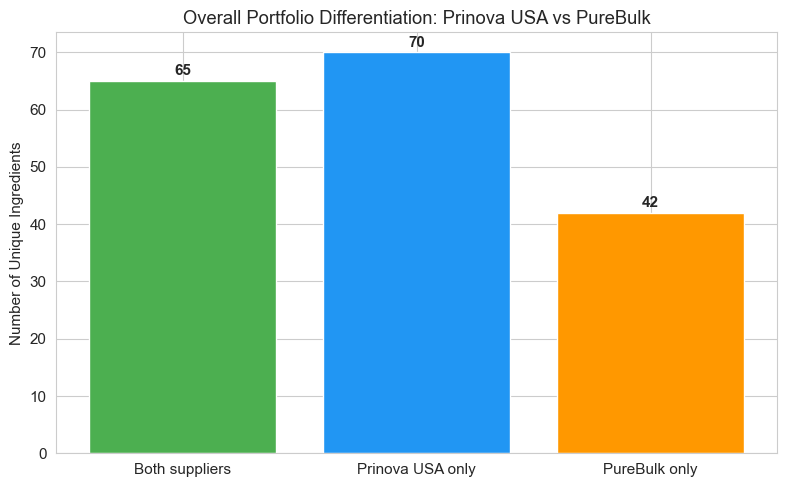

In [7]:
# Side-by-side comparison: what does each supplier carry that the other doesn't?
prinova_ings = set(all_sp[all_sp.Name == "Prinova USA"]["ingredient"].unique())
purebulk_ings = set(all_sp[all_sp.Name == "PureBulk"]["ingredient"].unique())

only_prinova = prinova_ings - purebulk_ings
only_purebulk = purebulk_ings - prinova_ings
both = prinova_ings & purebulk_ings

print(f"Ingredient overlap between the two Vitamin C suppliers:\n")
print(f"  Both carry:           {len(both):>4}")
print(f"  Only Prinova USA:     {len(only_prinova):>4}")
print(f"  Only PureBulk:        {len(only_purebulk):>4}")

if only_prinova:
    print(f"\n  Prinova-only ingredients: {', '.join(sorted(only_prinova)[:20])}")
if only_purebulk:
    print(f"\n  PureBulk-only ingredients: {', '.join(sorted(only_purebulk)[:20])}")

# Visualize overlap
fig, ax = plt.subplots(figsize=(8, 5))
data = pd.DataFrame({
    "Category": ["Both suppliers", "Prinova USA only", "PureBulk only"],
    "Count": [len(both), len(only_prinova), len(only_purebulk)]
})
ax.bar(data["Category"], data["Count"], color=["#4CAF50", "#2196F3", "#FF9800"])
ax.set_ylabel("Number of Unique Ingredients")
ax.set_title("Overall Portfolio Differentiation: Prinova USA vs PureBulk")
for i, v in enumerate(data["Count"]):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 3c. Company Brand Tier as Quality Signal

The companies using each supplier can serve as an indirect quality signal. Premium/pharma-adjacent brands (Centrum, Nature Made) vs. value/store brands (Equate, up&up) may have different quality requirements from their suppliers.

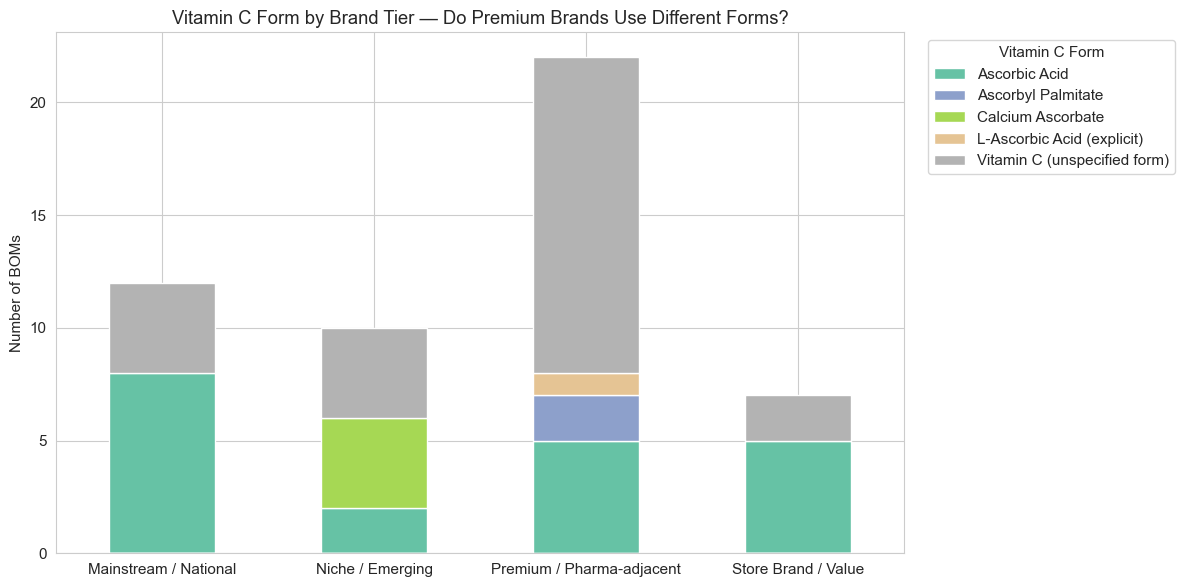


Detailed breakdown:


,Brand Tier,Vitamin C Form,Companies,BOMs
0,Mainstream / National,Ascorbic Acid,"Body Fortress, Kirkland Signature, Liquid I.V....",8
1,Mainstream / National,Vitamin C (unspecified form),"Body Fortress, The Vitamin Shoppe, Vitacost",4
2,Niche / Emerging,Ascorbic Acid,"ALL ONE, Nature's Nutrition",2
3,Niche / Emerging,Calcium Ascorbate,"TREVI, Ultima Replenisher",4
4,Niche / Emerging,Vitamin C (unspecified form),"BBEEAAUU, BodyTech, PowderVitamin, Wellmade",4
5,Premium / Pharma-adjacent,Ascorbic Acid,One A Day,5
6,Premium / Pharma-adjacent,Ascorbyl Palmitate,"NOW Foods, Nature's Bounty",2
7,Premium / Pharma-adjacent,L-Ascorbic Acid (explicit),NutriBiotic,1
8,Premium / Pharma-adjacent,Vitamin C (unspecified form),"Centrum, Nature Made, New Chapter, One A Day",14
9,Store Brand / Value,Ascorbic Acid,"Equate, Walgreens, up&up",5


In [8]:
# Classify companies into rough brand tiers based on known market positioning
BRAND_TIERS = {
    "Premium / Pharma-adjacent": ["Centrum", "Nature Made", "New Chapter", "Nature's Bounty",
                                   "Jarrow Formulas", "NOW Foods", "One A Day", "NutriBiotic",
                                   "Ritual"],
    "Mainstream / National": ["Kirkland Signature", "GNC", "The Vitamin Shoppe", "Vitacost",
                               "Liquid I.V.", "PRIME HYDRATION+", "Body Fortress"],
    "Store Brand / Value": ["Equate", "up&up", "CVS", "Walgreens", "Caltrate"],
    "Niche / Emerging": ["BBEEAAUU", "TREVI", "PowderVitamin", "Wellmade", "BodyTech",
                          "ALL ONE", "Ultima Replenisher", "Nature's Nutrition"],
}

def get_tier(company_name):
    for tier, brands in BRAND_TIERS.items():
        if company_name in brands:
            return tier
    return "Other"

bom_types_df["Brand Tier"] = bom_types_df["Company"].apply(get_tier)

# Which brand tiers use which vitamin C forms?
tier_form = pd.crosstab(bom_types_df["Brand Tier"], bom_types_df["Vitamin C Form"])

fig, ax = plt.subplots(figsize=(12, 6))
tier_form.plot.bar(ax=ax, stacked=True, colormap="Set2", edgecolor="white")
ax.set_ylabel("Number of BOMs")
ax.set_title("Vitamin C Form by Brand Tier — Do Premium Brands Use Different Forms?")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Vitamin C Form", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nDetailed breakdown:")
display(bom_types_df.groupby(["Brand Tier", "Vitamin C Form"]).agg(
    Companies=("Company", lambda x: ", ".join(sorted(x.unique()))),
    BOMs=("BOMId", "count")
).reset_index())

### 3d. Form Substitutability Map

Not all Vitamin C forms are interchangeable. Based on chemical properties, we can build a substitutability matrix showing which forms *could* replace each other (with caveats) and which absolutely cannot.

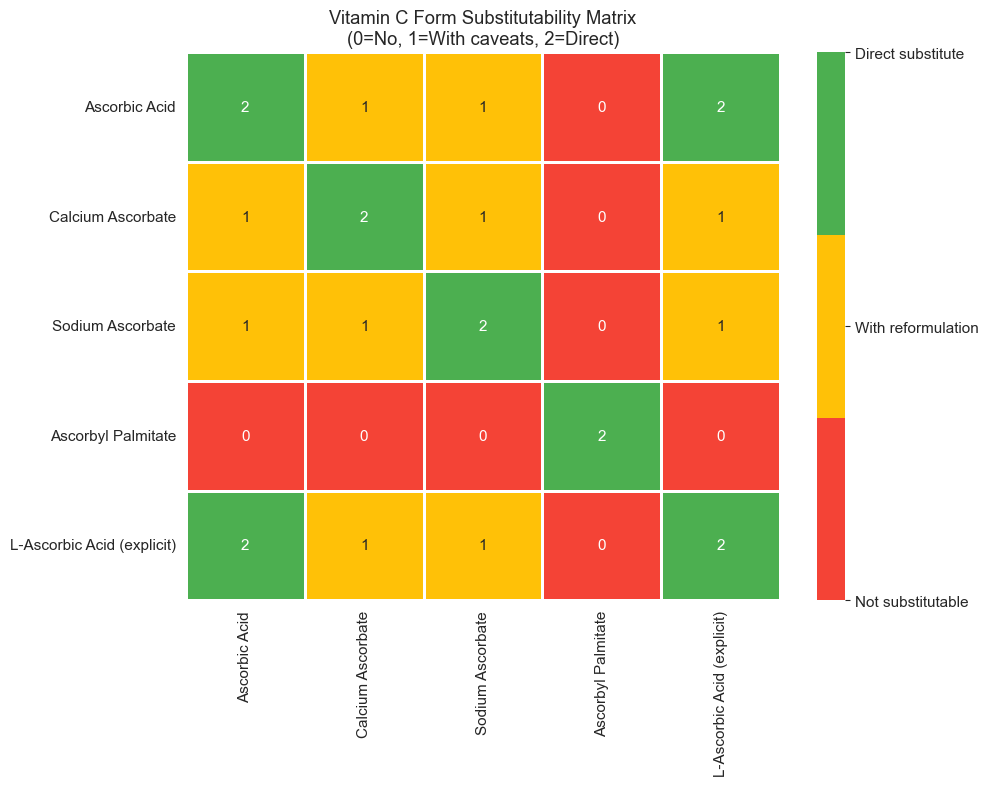

Key constraints for substitution:
  - Ascorbyl Palmitate is fat-soluble => CANNOT replace water-soluble forms in aqueous formulas
  - Calcium Ascorbate adds ~10% calcium => must adjust mineral claims on label
  - Sodium Ascorbate adds sodium => problematic in low-sodium products
  - Buffered forms (Ca/Na ascorbate) have pH ~7 vs pH ~2.5 for ascorbic acid
    => may affect stability of co-ingredients and flavor profile


In [9]:
# Form substitutability matrix
# 2 = direct substitute, 1 = possible with reformulation, 0 = not substitutable
forms = [
    "Ascorbic Acid",
    "Calcium Ascorbate",
    "Sodium Ascorbate",
    "Ascorbyl Palmitate",
    "L-Ascorbic Acid (explicit)",
]

# Reasoning:
# - Ascorbic acid <-> L-ascorbic acid: identical (L is the bioactive form, always implied)
# - Ascorbic acid <-> calcium/sodium ascorbate: possible but changes pH, adds mineral
# - Ascorbyl palmitate: fat-soluble, fundamentally different delivery mechanism
substitutability = pd.DataFrame(
    [
        #  AA  CaA  NaA  AP   LAA
        [  2,   1,   1,   0,   2],  # Ascorbic Acid
        [  1,   2,   1,   0,   1],  # Calcium Ascorbate
        [  1,   1,   2,   0,   1],  # Sodium Ascorbate
        [  0,   0,   0,   2,   0],  # Ascorbyl Palmitate
        [  2,   1,   1,   0,   2],  # L-Ascorbic Acid
    ],
    index=forms,
    columns=forms,
)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.color_palette(["#F44336", "#FFC107", "#4CAF50"], as_cmap=False)
custom_cmap = matplotlib.colors.ListedColormap(cmap)
sns.heatmap(substitutability, annot=True, fmt="d", cmap=custom_cmap,
            vmin=0, vmax=2, linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"ticks": [0, 1, 2]})
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(["Not substitutable", "With reformulation", "Direct substitute"])
ax.set_title("Vitamin C Form Substitutability Matrix\n(0=No, 1=With caveats, 2=Direct)")
plt.tight_layout()
plt.show()

print("Key constraints for substitution:")
print("  - Ascorbyl Palmitate is fat-soluble => CANNOT replace water-soluble forms in aqueous formulas")
print("  - Calcium Ascorbate adds ~10% calcium => must adjust mineral claims on label")
print("  - Sodium Ascorbate adds sodium => problematic in low-sodium products")
print("  - Buffered forms (Ca/Na ascorbate) have pH ~7 vs pH ~2.5 for ascorbic acid")
print("    => may affect stability of co-ingredients and flavor profile")

## 4. Consolidation Opportunity Within Vitamin C

Given the form constraints, how many BOMs could actually share a consolidated Vitamin C supply? Group by form to find the real consolidation pools.

Consolidation Pools (forms that are direct substitutes are merged):



,BOMs,Companies,Company_List
Consolidation Pool,,,
"Ascorbic Acid (water-soluble, unbuffered)",45,20,"ALL ONE, BBEEAAUU, Body Fortress, BodyTech, Ce..."
Calcium Ascorbate (buffered),4,2,"TREVI, Ultima Replenisher"
Ascorbyl Palmitate (fat-soluble),2,2,"NOW Foods, Nature's Bounty"


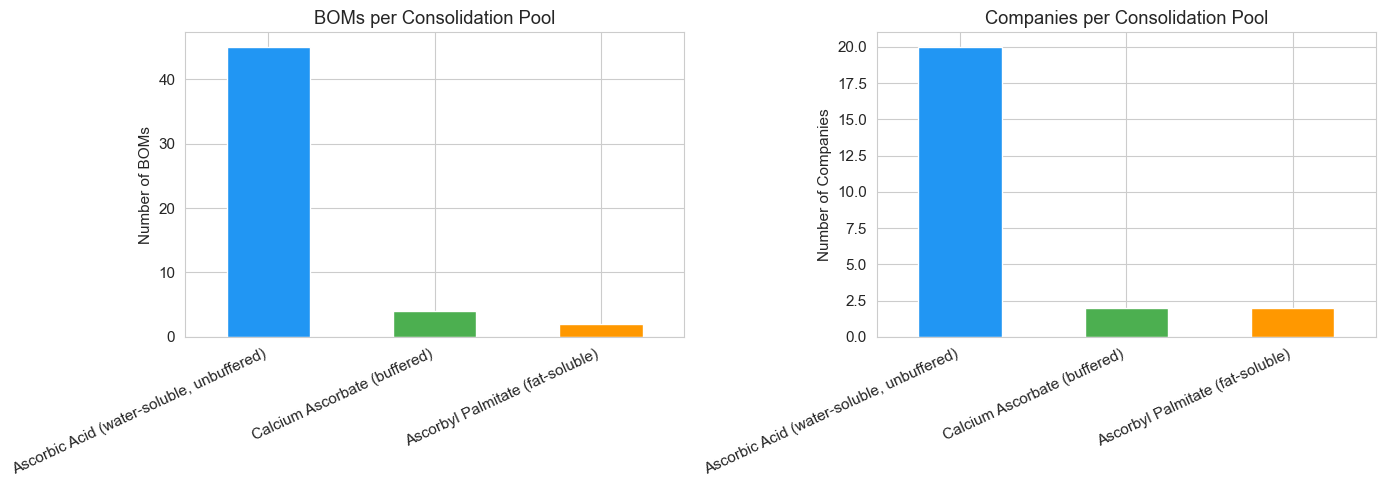


Largest pool: Ascorbic Acid (water-soluble, unbuffered)
  45 BOMs across 20 companies
  => strongest candidate for volume consolidation


In [10]:
# Group BOMs into consolidation pools by Vitamin C form
# Merge forms that are direct substitutes
def normalize_form(form):
    if form in ("Ascorbic Acid", "L-Ascorbic Acid (explicit)", "Vitamin C (unspecified form)"):
        return "Ascorbic Acid (water-soluble, unbuffered)"
    elif form == "Calcium Ascorbate":
        return "Calcium Ascorbate (buffered)"
    elif form == "Sodium Ascorbate":
        return "Sodium Ascorbate (buffered)"
    elif form == "Ascorbyl Palmitate":
        return "Ascorbyl Palmitate (fat-soluble)"
    return form

bom_types_df["Consolidation Pool"] = bom_types_df["Vitamin C Form"].apply(normalize_form)

pool_summary = (
    bom_types_df.groupby("Consolidation Pool")
    .agg(
        BOMs=("BOMId", "count"),
        Companies=("Company", "nunique"),
        Company_List=("Company", lambda x: ", ".join(sorted(x.unique()))),
    )
    .sort_values("BOMs", ascending=False)
)

print("Consolidation Pools (forms that are direct substitutes are merged):\n")
display(pool_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pool_summary["BOMs"].plot.bar(ax=axes[0], color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"])
axes[0].set_title("BOMs per Consolidation Pool")
axes[0].set_ylabel("Number of BOMs")
axes[0].set_xlabel("")
plt.sca(axes[0])
plt.xticks(rotation=25, ha="right")

pool_summary["Companies"].plot.bar(ax=axes[1], color=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"])
axes[1].set_title("Companies per Consolidation Pool")
axes[1].set_ylabel("Number of Companies")
axes[1].set_xlabel("")
plt.sca(axes[1])
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

print(f"\nLargest pool: {pool_summary.index[0]}")
print(f"  {pool_summary.iloc[0]['BOMs']} BOMs across {pool_summary.iloc[0]['Companies']} companies")
print(f"  => strongest candidate for volume consolidation")

## 5. The External Data Gap — What We NEED to Compare Suppliers

The database tells us **who buys what form from whom**, but nothing about **quality, cost, or compliance**. Below is a structured framework of the external data dimensions needed to make real sourcing decisions for Vitamin C.

In [11]:
# External data framework for Vitamin C supplier evaluation
external_data = pd.DataFrame([
    {
        "Dimension": "Purity & Grade",
        "What to Look For": "USP/FCC/EP grade designation; assay % (typically 99.0-100.5%); "
                            "pharma-grade vs food-grade vs technical-grade",
        "Where to Find It": "Supplier spec sheets, Certificates of Analysis (CoA), "
                            "USP Verified database, supplier product catalogs",
        "Why It Matters": "Pharma-grade ascorbic acid commands 20-40% premium but is required "
                          "for USP-verified finished products. Food-grade is sufficient for most supplements.",
        "Priority": "Critical",
    },
    {
        "Dimension": "Manufacturing Origin",
        "What to Look For": "Country of manufacture (China produces ~95% of global ascorbic acid); "
                            "specific manufacturer (DSM, CSPC Weisheng, Northeast Pharma, Shandong Luwei)",
        "Where to Find It": "Supplier websites, import/export databases (ImportGenius, Panjiva), "
                            "FDA facility registrations",
        "Why It Matters": "Chinese vs European origin can affect pricing (2-5x), perceived quality, "
                          "and supply chain resilience. Non-GMO origin matters for clean-label brands.",
        "Priority": "Critical",
    },
    {
        "Dimension": "Certifications",
        "What to Look For": "GMP (cGMP for pharma), NSF International, USP Verified, "
                            "Non-GMO Project Verified, Organic (USDA/EU), Kosher, Halal, ISO 22000",
        "Where to Find It": "NSF certified product database, USDA organic database, "
                            "Non-GMO Project product directory, supplier websites",
        "Why It Matters": "Certifications are non-negotiable for certain end products. "
                          "A USP-verified multivitamin REQUIRES USP-grade inputs. "
                          "Organic/Non-GMO claims require certified supply chain.",
        "Priority": "Critical",
    },
    {
        "Dimension": "Heavy Metal Testing",
        "What to Look For": "Lead, arsenic, cadmium, mercury limits (typically <1 ppm each); "
                            "California Prop 65 compliance; third-party testing reports",
        "Where to Find It": "Certificates of Analysis, NSF/ConsumerLab test results, "
                            "Prop 65 settlement databases",
        "Why It Matters": "Heavy metal contamination is the #1 regulatory risk for vitamin C. "
                          "Products sold in California must meet Prop 65 thresholds or carry warnings.",
        "Priority": "Critical",
    },
    {
        "Dimension": "Price & Commercial Terms",
        "What to Look For": "Price per kg by grade/form, MOQ (minimum order quantity), "
                            "lead time, payment terms, volume discount tiers",
        "Where to Find It": "Supplier quotes, distributor price lists, bulk ingredient marketplaces "
                            "(e.g., Alibaba for reference pricing), trade publications",
        "Why It Matters": "Ascorbic acid ranges from ~$8/kg (Chinese bulk) to ~$40/kg (European pharma-grade). "
                          "Ascorbyl palmitate is 3-5x more expensive than ascorbic acid.",
        "Priority": "High",
    },
    {
        "Dimension": "Physical Specifications",
        "What to Look For": "Particle size (mesh), bulk density, flowability, moisture content, "
                            "DC-grade (directly compressible) vs standard powder vs granular",
        "Where to Find It": "Technical data sheets (TDS), supplier spec sheets",
        "Why It Matters": "Tablet manufacturers need DC-grade for direct compression. "
                          "Beverage companies need fine powder for solubility. "
                          "Wrong particle size = reformulation cost.",
        "Priority": "High",
    },
    {
        "Dimension": "Stability & Shelf Life",
        "What to Look For": "Accelerated stability data, recommended storage conditions, "
                            "retest date (typically 2-3 years for ascorbic acid)",
        "Where to Find It": "Supplier stability studies, CoA with manufacturing/retest dates",
        "Why It Matters": "Ascorbic acid degrades with heat, light, moisture, and oxygen. "
                          "Buffered forms (Ca/Na ascorbate) are more stable. "
                          "Finished product shelf life depends on ingredient stability.",
        "Priority": "Medium",
    },
    {
        "Dimension": "Production Method",
        "What to Look For": "Reichstein process (chemical synthesis from glucose) vs "
                            "two-step fermentation (bacterial); GMO vs non-GMO glucose source",
        "Where to Find It": "Supplier technical documentation, patent filings, "
                            "Non-GMO Project verification records",
        "Why It Matters": "Most ascorbic acid uses corn-derived glucose (GMO concern). "
                          "Fermentation-based may appeal to clean-label positioning. "
                          "Method affects impurity profile.",
        "Priority": "Medium",
    },
    {
        "Dimension": "Supply Chain Resilience",
        "What to Look For": "Number of manufacturing sites, geographic diversification, "
                            "inventory buffer policy, historical supply disruption record",
        "Where to Find It": "Supplier questionnaires, Dun & Bradstreet reports, "
                            "FDA warning letters database, trade press",
        "Why It Matters": "COVID exposed single-source China risk for vitamin C. "
                          "Dual-sourcing from China + Europe adds ~15% cost but reduces disruption risk.",
        "Priority": "Medium",
    },
    {
        "Dimension": "Regulatory Status",
        "What to Look For": "FDA GRAS status, EU Novel Food compliance, EFSA approved health claims, "
                            "DMF (Drug Master File) for pharma applications",
        "Where to Find It": "FDA GRAS notice inventory, EU Novel Food catalogue, "
                            "EFSA register of health claims, FDA DMF database",
        "Why It Matters": "Regulatory status determines which markets and product claims are available. "
                          "A supplier with DMF filing enables pharma-grade positioning.",
        "Priority": "Medium",
    },
])

# Display as formatted table
print("EXTERNAL DATA FRAMEWORK FOR VITAMIN C SUPPLIER EVALUATION\n")
for _, row in external_data.iterrows():
    print(f"[{row['Priority']:8s}]  {row['Dimension']}")
    print(f"           Look for: {row['What to Look For'][:90]}...")
    print(f"           Source:   {row['Where to Find It'][:90]}...")
    print()

EXTERNAL DATA FRAMEWORK FOR VITAMIN C SUPPLIER EVALUATION

[Critical]  Purity & Grade
           Look for: USP/FCC/EP grade designation; assay % (typically 99.0-100.5%); pharma-grade vs food-grade ...
           Source:   Supplier spec sheets, Certificates of Analysis (CoA), USP Verified database, supplier prod...

[Critical]  Manufacturing Origin
           Look for: Country of manufacture (China produces ~95% of global ascorbic acid); specific manufacture...
           Source:   Supplier websites, import/export databases (ImportGenius, Panjiva), FDA facility registrat...

[Critical]  Certifications
           Look for: GMP (cGMP for pharma), NSF International, USP Verified, Non-GMO Project Verified, Organic ...
           Source:   NSF certified product database, USDA organic database, Non-GMO Project product directory, ...

[Critical]  Heavy Metal Testing
           Look for: Lead, arsenic, cadmium, mercury limits (typically <1 ppm each); California Prop 65 complia...
           Sou

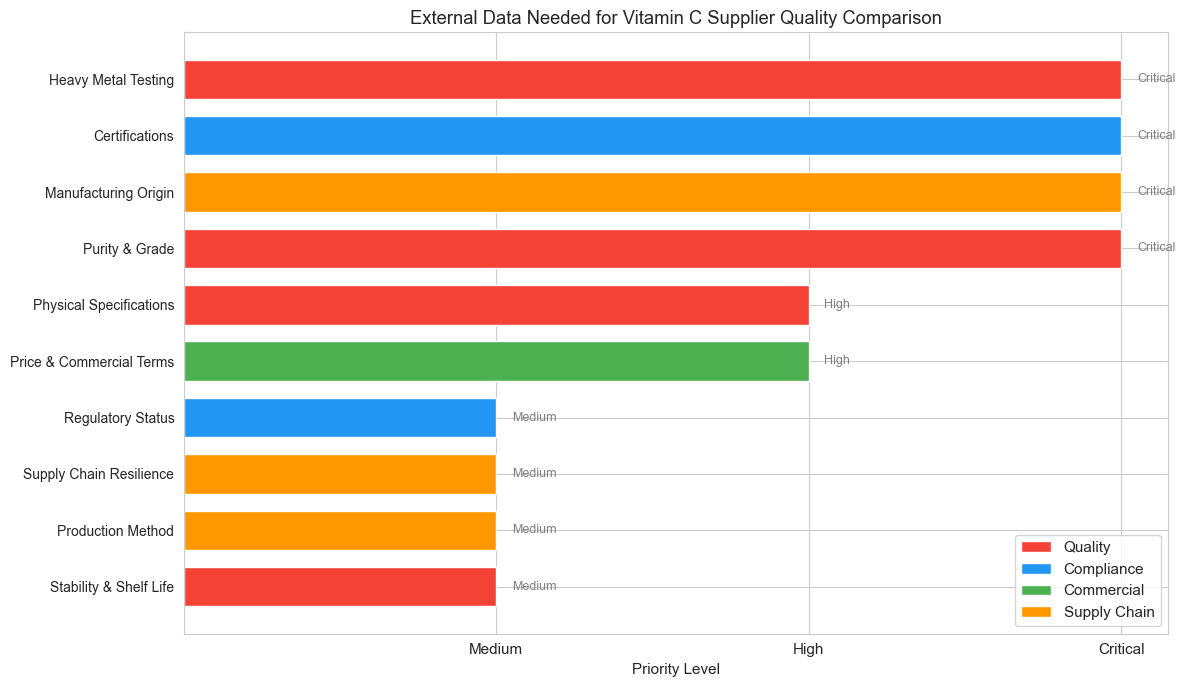

In [12]:
# Visualize the external data framework by priority and category
external_data["Category"] = external_data["Dimension"].map({
    "Purity & Grade": "Quality",
    "Manufacturing Origin": "Supply Chain",
    "Certifications": "Compliance",
    "Heavy Metal Testing": "Quality",
    "Price & Commercial Terms": "Commercial",
    "Physical Specifications": "Quality",
    "Stability & Shelf Life": "Quality",
    "Production Method": "Supply Chain",
    "Supply Chain Resilience": "Supply Chain",
    "Regulatory Status": "Compliance",
})

priority_order = {"Critical": 3, "High": 2, "Medium": 1}
external_data["priority_score"] = external_data["Priority"].map(priority_order)

fig, ax = plt.subplots(figsize=(12, 7))
cat_colors = {"Quality": "#F44336", "Compliance": "#2196F3", "Commercial": "#4CAF50", "Supply Chain": "#FF9800"}

for i, (_, row) in enumerate(external_data.sort_values("priority_score", ascending=True).iterrows()):
    ax.barh(i, row["priority_score"], color=cat_colors[row["Category"]], edgecolor="white", height=0.7)
    ax.text(row["priority_score"] + 0.05, i, row["Priority"], va="center", fontsize=9, color="gray")

ax.set_yticks(range(len(external_data)))
ax.set_yticklabels(external_data.sort_values("priority_score", ascending=True)["Dimension"], fontsize=10)
ax.set_xlabel("Priority Level")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Medium", "High", "Critical"])
ax.set_title("External Data Needed for Vitamin C Supplier Quality Comparison")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in cat_colors.items()]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## 6. Hypothetical Enriched Supplier Comparison

To demonstrate what a complete analysis would look like, here is a mock comparison of Prinova USA vs PureBulk using realistic external data dimensions. In a real system, Agnes would populate this by scraping supplier websites, querying certification databases, and pulling import records.

HYPOTHETICAL ENRICHED SUPPLIER COMPARISON
(based on publicly available information about these supplier types)



,Prinova USA,PureBulk
Dimension,,
Company Type,B2B ingredient distributor,DTC / small-batch distributor
Parent / Ownership,"Nagase Group (Japan, $7B+ revenue)",Independent (US-based)
Grades Offered,"USP, FCC, pharma-grade","FCC, food-grade"
Ascorbic Acid Price (est.),$12-18/kg (volume-dependent),$10-15/kg
Ascorbyl Palmitate Price (est.),$45-60/kg,$40-55/kg
MOQ,500 kg+,1 kg (retail) / 25 kg (wholesale)
Lead Time,2-4 weeks (domestic stock),1-2 weeks (domestic stock)
GMP Certified,Yes,Facility is GMP
NSF Registered,Yes,Not listed


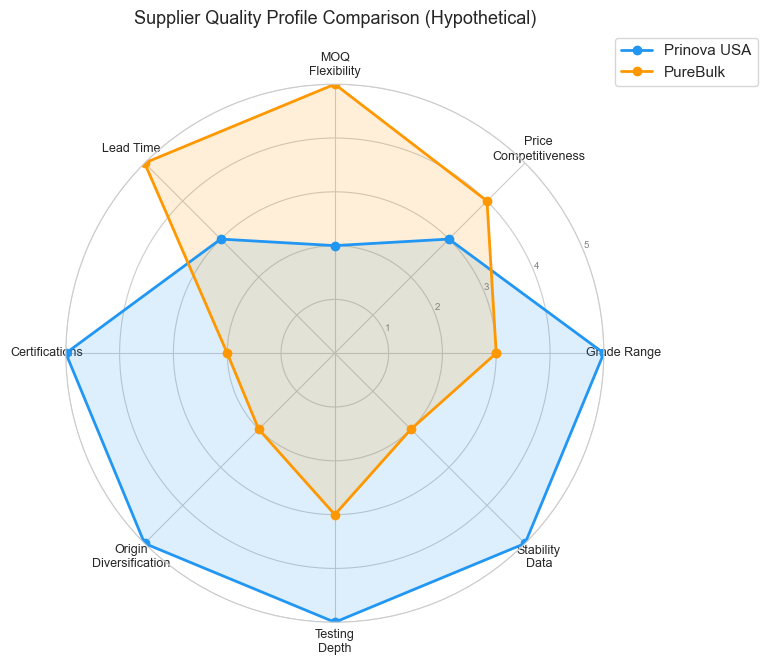

Interpretation:
  Prinova USA: stronger on compliance, certifications, and supply chain depth
  PureBulk:    stronger on price, MOQ flexibility, and speed
  => Prinova better for premium/pharma brands; PureBulk better for cost-sensitive/small-batch


In [13]:
# Hypothetical enriched supplier profiles (realistic based on public info about these companies)
# Prinova USA: large ingredient distributor, part of Nagase Group
# PureBulk: smaller, DTC-focused bulk supplement ingredient supplier

enriched_comparison = pd.DataFrame({
    "Dimension": [
        "Company Type",
        "Parent / Ownership",
        "Grades Offered",
        "Ascorbic Acid Price (est.)",
        "Ascorbyl Palmitate Price (est.)",
        "MOQ",
        "Lead Time",
        "GMP Certified",
        "NSF Registered",
        "Non-GMO Available",
        "Kosher / Halal",
        "Primary Origin",
        "Geographic Diversification",
        "Particle Size Options",
        "CoA with Each Lot",
        "Heavy Metal Testing",
        "Stability Data Available",
    ],
    "Prinova USA": [
        "B2B ingredient distributor",
        "Nagase Group (Japan, $7B+ revenue)",
        "USP, FCC, pharma-grade",
        "$12-18/kg (volume-dependent)",
        "$45-60/kg",
        "500 kg+",
        "2-4 weeks (domestic stock)",
        "Yes",
        "Yes",
        "Yes (verified supply chain)",
        "Yes / Yes",
        "China (CSPC, Northeast Pharma), Europe (DSM)",
        "High (multiple sourcing countries)",
        "Fine, granular, DC-grade",
        "Yes (standard)",
        "Pb, As, Cd, Hg (standard panel)",
        "Yes (accelerated + real-time)",
    ],
    "PureBulk": [
        "DTC / small-batch distributor",
        "Independent (US-based)",
        "FCC, food-grade",
        "$10-15/kg",
        "$40-55/kg",
        "1 kg (retail) / 25 kg (wholesale)",
        "1-2 weeks (domestic stock)",
        "Facility is GMP",
        "Not listed",
        "Some products",
        "Kosher available",
        "China (various)",
        "Low (primarily single-source)",
        "Standard powder",
        "Available on request",
        "Basic panel",
        "Limited",
    ],
})

# Display as styled comparison table
print("HYPOTHETICAL ENRICHED SUPPLIER COMPARISON")
print("(based on publicly available information about these supplier types)\n")
display(enriched_comparison.set_index("Dimension"))

# Radar chart comparison
import matplotlib.pyplot as plt
from math import pi

categories_radar = [
    "Grade Range", "Price\nCompetitiveness", "MOQ\nFlexibility",
    "Lead Time", "Certifications", "Origin\nDiversification",
    "Testing\nDepth", "Stability\nData"
]
# Scores 1-5
prinova_scores = [5, 3, 2, 3, 5, 5, 5, 5]
purebulk_scores = [3, 4, 5, 5, 2, 2, 3, 2]

N = len(categories_radar)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

prinova_scores_plot = prinova_scores + prinova_scores[:1]
purebulk_scores_plot = purebulk_scores + purebulk_scores[:1]

ax.plot(angles, prinova_scores_plot, "o-", linewidth=2, label="Prinova USA", color="#2196F3")
ax.fill(angles, prinova_scores_plot, alpha=0.15, color="#2196F3")
ax.plot(angles, purebulk_scores_plot, "o-", linewidth=2, label="PureBulk", color="#FF9800")
ax.fill(angles, purebulk_scores_plot, alpha=0.15, color="#FF9800")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=9)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7, color="gray")
ax.set_title("Supplier Quality Profile Comparison (Hypothetical)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Prinova USA: stronger on compliance, certifications, and supply chain depth")
print("  PureBulk:    stronger on price, MOQ flexibility, and speed")
print("  => Prinova better for premium/pharma brands; PureBulk better for cost-sensitive/small-batch")

## 7. Summary: What the Data Tells Us vs What It Can't

In [14]:
print("""
============================================================
VITAMIN C SUPPLIER ANALYSIS — KEY FINDINGS
============================================================

WHAT THE DATABASE TELLS US:
  1. 31 Vitamin C products across 22 companies in 51 BOMs
  2. 5 distinct chemical forms (ascorbic acid, ascorbyl palmitate,
     calcium ascorbate, sodium ascorbate, generic "vitamin C")
  3. Only 2 suppliers (Prinova USA, PureBulk) — with IDENTICAL
     product coverage. No differentiation in the data.
  4. Form usage correlates with product type:
     - Multivitamins: generic vitamin C / ascorbic acid
     - Electrolyte drinks: calcium ascorbate (buffered)
     - Softgels/oils: ascorbyl palmitate (fat-soluble)
  5. Ascorbyl palmitate is NOT substitutable with water-soluble forms

WHAT WE CAN INFER (indirect signals):
  - Chemical form => constrains grade & application requirements
  - BOM co-ingredients => reveals product type => constrains quality tier
  - Brand tier (premium vs store brand) => implies quality expectations
  - Supplier portfolio breadth => distributor vs specialist signal

WHAT WE CANNOT INFER (requires external enrichment):
  [CRITICAL] Purity / grade (USP vs FCC vs food-grade)
  [CRITICAL] Manufacturing origin (China vs Europe)
  [CRITICAL] Certifications (NSF, Non-GMO, Kosher, Halal)
  [CRITICAL] Heavy metal testing & Prop 65 compliance
  [HIGH]     Price, MOQ, lead time
  [HIGH]     Physical specs (particle size, DC-grade)
  [MEDIUM]   Stability data, production method, supply resilience
  [MEDIUM]   Regulatory status (GRAS, DMF, EFSA)

CONSOLIDATION OPPORTUNITY:
  The largest pool (ascorbic acid, water-soluble) spans ~44 BOMs
  across ~20 companies — massive volume leverage if a single
  supplier can meet all grade/certification requirements.
  But this requires external verification of supplier capabilities.
""")

conn.close()


VITAMIN C SUPPLIER ANALYSIS — KEY FINDINGS

WHAT THE DATABASE TELLS US:
  1. 31 Vitamin C products across 22 companies in 51 BOMs
  2. 5 distinct chemical forms (ascorbic acid, ascorbyl palmitate,
     calcium ascorbate, sodium ascorbate, generic "vitamin C")
  3. Only 2 suppliers (Prinova USA, PureBulk) — with IDENTICAL
     product coverage. No differentiation in the data.
  4. Form usage correlates with product type:
     - Multivitamins: generic vitamin C / ascorbic acid
     - Electrolyte drinks: calcium ascorbate (buffered)
     - Softgels/oils: ascorbyl palmitate (fat-soluble)
  5. Ascorbyl palmitate is NOT substitutable with water-soluble forms

WHAT WE CAN INFER (indirect signals):
  - Chemical form => constrains grade & application requirements
  - BOM co-ingredients => reveals product type => constrains quality tier
  - Brand tier (premium vs store brand) => implies quality expectations
  - Supplier portfolio breadth => distributor vs specialist signal

WHAT WE CANNOT INFER